## Notebook to compare, binary, adaptive global, and iterative global methods of finding circles.
This compares the best binary approach with 3 adaptive global thresholds and 3 iterative global thresholds to see what returns us the best accuracy for time spent trying to find the circles.

The binary threshold is set to 180

The adaptives drop from the found global maximum by 20, 50, and 80.

The iterative tests 2 thresholds, 5 thresholds, and 10 threshold attempts.

In [ ]:
## Import Cell
import json
import statistics as stats
import pandas as pd
import puck.experiments.best_thresholding.iterative_adaptive_binary_accuracy as iaba
import matplotlib.pyplot as plt

output_file_name returns the path name of the output file generated from iaba.main()

cli_printout prints out some metadata to the command line interface, because you're using the notebook to access this, I recommend turnning it off.

A progress bar will show up beneath the cell that is running this, you can use this to approximate how long the cell will take to run. The more hyperparameters tested, the more time it will likely take.

In [3]:
output_file_name = iaba.main(
    input_path="../data/images_miniset",
    ground_truth="../data/annotations/annotations.json", 
    output_folder="../output/experimental_results/",
    output_name="iterative_adaptive_binary", 
    cli_output=False
)

100%|██████████| 7/7 [00:27<00:00,  3.89s/it]


In [ ]:
## Open the file data and inspect that everything is about right
## note that close4_acc means four of the found dots were close enough to the ground truth whereas correct_acc measures if there were only 4 dots found and all four were close enough to the ground truths
with open(output_file_name, "r") as json_file:
    file_data = dict(json.loads(json_file.read()))
file_data

In [ ]:
# acquiire two key lists so you can seperate out the close4_acc and the correct_acc results
correct_acc_key_list = [k for k in file_data.keys() if "correct_acc" in k]
close4_acc_key_list = [k for k in file_data.keys() if "close4_acc" in k]

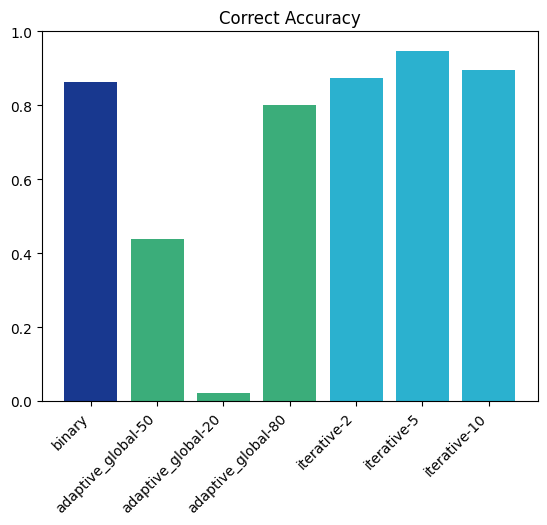

In [ ]:
# plot out the correct accuracy with colours assigned based on the method used.
keys = []
values = []
for key, value in file_data.items():
    if key in correct_acc_key_list:
        keys.append(key[:-12])
        values.append(value)

plt.bar(
    x=keys,
    height=values,
    color=['#18388f', '#3bad7a', '#3bad7a', '#3bad7a', '#2bb1cf', '#2bb1cf', '#2bb1cf'],
    )
plt.title("Correct Accuracy")
plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.show()

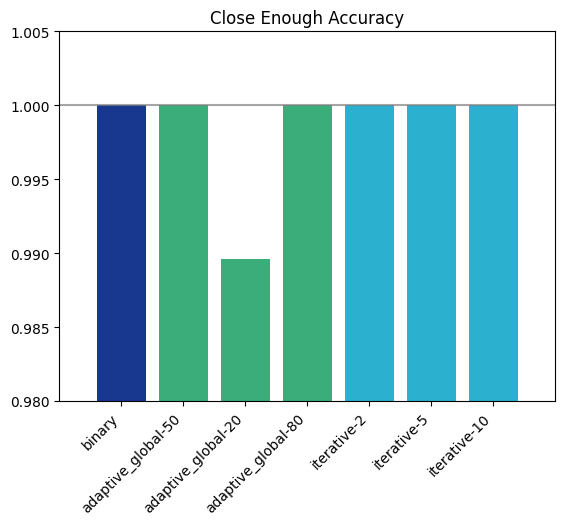

In [ ]:
# plot out the close enough for four of the dots found accuracy with colours assigned based on the method used.
# an extra line is put at 1 to show how many of the methods always had 4 dots close enough to the ground truth.

keys_2 = []
values_2 = []
for key, value in file_data.items():
    if key in close4_acc_key_list:
        keys_2.append(key[:-11])
        values_2.append(value)

plt.bar(
    x=keys_2,
    height=values_2,
    color=['#18388f', '#3bad7a', '#3bad7a', '#3bad7a', '#2bb1cf', '#2bb1cf', '#2bb1cf'],
    )
plt.hlines(y=1, xmin=-1, xmax=7, colors="gray", alpha = .7, label= "1")
plt.xlim(-1,7)
plt.title("Close Enough Accuracy")
plt.xticks(rotation=45, ha='right')
plt.ylim(.98,1.005)
plt.show()